# Rain in Australia — Logistic Regression Classifier
Same preprocessing pipeline as the SVM notebook, but using **Logistic Regression**.

Logistic Regression is a linear model that estimates the probability of a binary outcome. It is fast, interpretable via coefficients, and natively outputs calibrated probabilities — making ROC-AUC straightforward to compute.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

from scipy.stats import loguniform, uniform
from imblearn.over_sampling import SMOTE

df = pd.read_csv("./data/weatherAUS.csv")
print(df.shape)
print(df.dtypes)

(145460, 23)
Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object


## Step 1 — Clean the data

In [2]:
# Drop rows where target is missing
df.dropna(subset=['RainTomorrow'], inplace=True)

# Drop high-missing columns (>40%)
df.drop(columns=['Sunshine', 'Evaporation'], inplace=True)

print(f"Shape after cleaning: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Shape after cleaning: (142193, 21)
Missing values:
MinTemp            637
MaxTemp            322
Rainfall          1406
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
dtype: int64


## Step 2 — Feature engineering

In [3]:
# DateTime features
df['Date'] = pd.to_datetime(df['Date'])
df['Month']      = df['Date'].dt.month
df['Year']       = df['Date'].dt.year
df['DayOfYear']  = df['Date'].dt.dayofyear   # captures seasonality
df.drop(columns=['Date'], inplace=True)

# Useful derived features
df['TempRange']       = df['MaxTemp'] - df['MinTemp']        # daily temp swing
df['PressureDrop']    = df['Pressure9am'] - df['Pressure3pm'] # falling pressure = rain
df['HumidityChange']  = df['Humidity3pm'] - df['Humidity9am'] # rising humidity = rain
df['WindSpeedChange'] = df['WindSpeed3pm'] - df['WindSpeed9am']

# Encode target
df['RainTomorrow'] = (df['RainTomorrow'] == 'Yes').astype(int)
df['RainToday']    = (df['RainToday'] == 'Yes').astype(int)
df.fillna({'RainToday': 0}, inplace=True)

## Step 3 — Encode categoricals

In [4]:
# WindGustDir, WindDir9am, WindDir3pm → 16 compass directions
wind_dirs = ['WindGustDir', 'WindDir9am', 'WindDir3pm']
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[wind_dirs] = ord_enc.fit_transform(df[wind_dirs])

# Location → 49 cities → use frequency encoding
loc_freq = df['Location'].value_counts() / len(df)
df['Location'] = df['Location'].map(loc_freq)

## Step 4 — Impute & split

In [5]:
# Separate features and target
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

# Impute numerics with median
num_cols = X.select_dtypes(include='number').columns
imputer  = SimpleImputer(strategy='median')
X[num_cols] = imputer.fit_transform(X[num_cols])

print(f"Missing after imputation: {X.isnull().sum().sum()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Class balance (train):\n{y_train.value_counts(normalize=True)}")

Missing after imputation: 0
Train: (113754, 26) | Test: (28439, 26)
Class balance (train):
RainTomorrow
0    0.775814
1    0.224186
Name: proportion, dtype: float64


## Step 5 — SMOTE (on training set only)

> **Note:** Logistic Regression is sensitive to feature scale, so we apply `StandardScaler` *after* SMOTE and *before* fitting.

In [6]:
# ⚠️ Apply SMOTE ONLY on training data — never on test data
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_bal).value_counts().to_dict()}")

c:\Users\ASUS TUF\anaconda3\envs\mlassignmentenv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\ASUS TUF\anaconda3\envs\mlassignmentenv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ASUS TUF\anaconda3\envs\mlassignmentenv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\ASUS TUF\anaconda3\envs\mlassignmentenv\Lib\subprocess.py", line 548, in run
    with

Before SMOTE: {0: 88252, 1: 25502}
After SMOTE:  {0: 88252, 1: 88252}


## Step 6 — Scale features

Logistic Regression converges faster and more reliably when features are standardised. We fit the scaler on the (SMOTE-augmented) training set and apply it to the test set.

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)   # fit on train only
X_test_scaled  = scaler.transform(X_test)            # apply same scaler to test

print("Scaling done. Train shape:", X_train_scaled.shape)

Scaling done. Train shape: (176504, 26)


## Step 7 — Train baseline Logistic Regression

We use `LogisticRegression` with `max_iter=1000` to ensure convergence on this dataset.

**Key differences from SVM:**
- Natively outputs `predict_proba` — no calibration wrapper needed.
- Much faster on large datasets than kernel SVM.
- Coefficients are directly interpretable as log-odds weights.

In [8]:
lr_baseline = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr_baseline.fit(X_train_scaled, y_train_bal)
print("Baseline model trained.")

Baseline model trained.


## Step 8 — Tune hyperparameters with RandomizedSearchCV

Key Logistic Regression hyperparameters:
- **C** — inverse of regularisation strength (larger C = less regularisation)
- **penalty** — regularisation type: `l1` (sparse), `l2` (default), `elasticnet`
- **solver** — must be compatible with the chosen penalty:
  - `saga` supports l1, l2, and elasticnet
  - `lbfgs` supports only l2

In [9]:
param_dist = {
    'C':       loguniform(1e-3, 100),          # regularisation strength
    'penalty': ['l1', 'l2', 'elasticnet'],
    'l1_ratio': uniform(0, 1),                 # only used when penalty='elasticnet'
}

base_lr = LogisticRegression(
    solver='saga',        # supports l1, l2, and elasticnet
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    base_lr,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

search.fit(X_train_scaled, y_train_bal)

print("Best Params:", search.best_params_)
print("Best CV AUC:", round(search.best_score_, 4))

lr_best = search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits


c:\Users\ASUS TUF\anaconda3\envs\mlassignmentenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Best Params: {'C': np.float64(1.0129197956845732), 'l1_ratio': np.float64(0.7080725777960455), 'penalty': 'l2'}
Best CV AUC: 0.8635


## Step 9 — Evaluate on the test set

              precision    recall  f1-score   support

     No Rain       0.92      0.79      0.85     22064
        Rain       0.52      0.78      0.62      6375

    accuracy                           0.79     28439
   macro avg       0.72      0.78      0.74     28439
weighted avg       0.83      0.79      0.80     28439

ROC-AUC: 0.8641


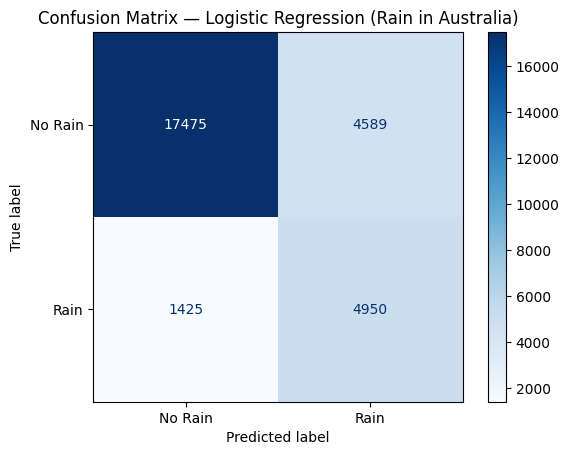

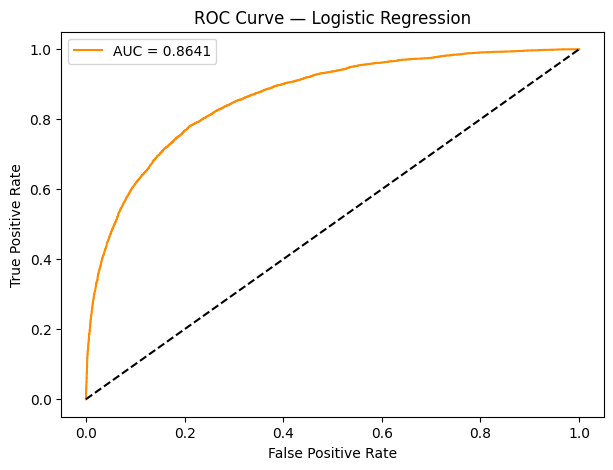

In [10]:
y_pred  = lr_best.predict(X_test_scaled)
y_proba = lr_best.predict_proba(X_test_scaled)[:, 1]

# ── Classification Report ─────────────────────────────────────────────────────
print(classification_report(y_test, y_pred, target_names=['No Rain', 'Rain']))

# ── ROC-AUC ───────────────────────────────────────────────────────────────────
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.4f}")

# ── Confusion Matrix ──────────────────────────────────────────────────────────
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Rain', 'Rain'],
    cmap='Blues'
)
plt.title("Confusion Matrix — Logistic Regression (Rain in Australia)")
plt.show()

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.show()

## Step 10 — Cross-validation score

In [11]:
cv_scores = cross_val_score(
    lr_best, X_train_scaled, y_train_bal,
    cv=5, scoring='roc_auc', n_jobs=-1
)
print(f"CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV ROC-AUC: 0.8635 ± 0.0032


## Step 11 — Feature importance (log-odds coefficients)

Unlike SVM, Logistic Regression gives us directly interpretable coefficients. A positive coefficient increases the log-odds of rain; a negative one decreases it.

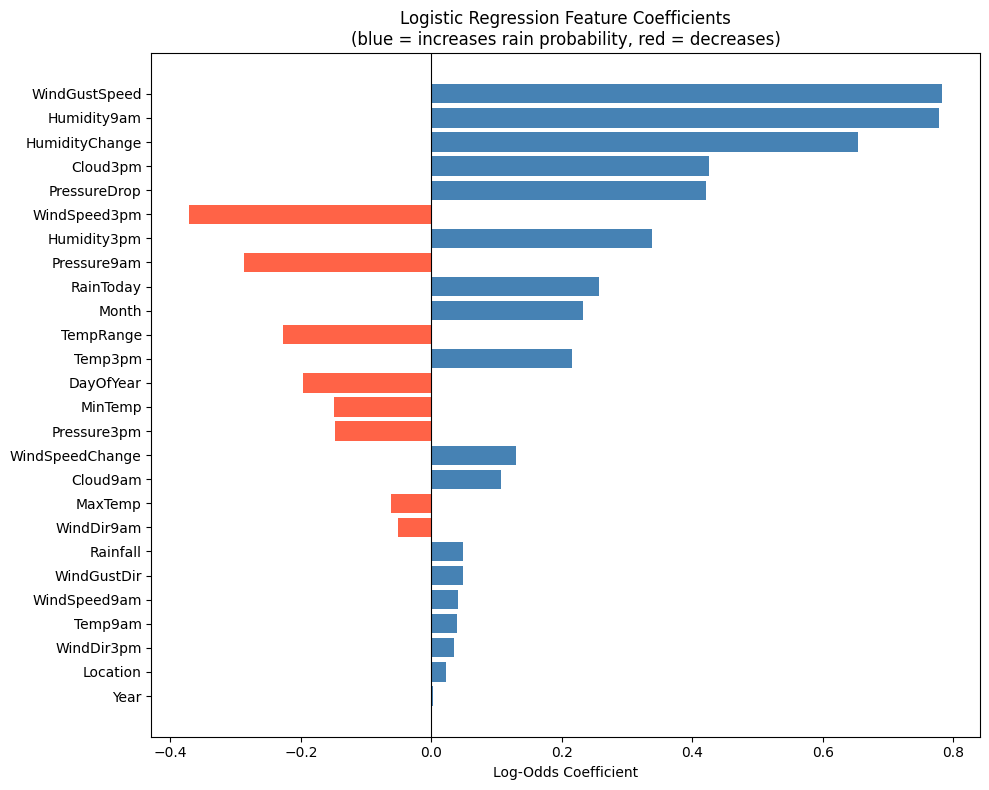

In [12]:
feature_names = X.columns.tolist()
coefs = lr_best.coef_[0]

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 8))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Log-Odds Coefficient")
plt.title("Logistic Regression Feature Coefficients\n(blue = increases rain probability, red = decreases)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## Notes on Logistic Regression vs SVM for this task

| Aspect | Logistic Regression | SVM (RBF) |
|--------|---------------------|----------|
| **Scaling required** | ✅ Yes | ✅ Yes |
| **Training speed (large data)** | 🚀 Fast | 🐢 Slow (O(n²–n³)) |
| **Interpretability** | ✅ High (coefficients = log-odds) | ❌ Low |
| **Probability output** | ✅ Native `predict_proba` | ⚠️ Needs Platt scaling |
| **Non-linear boundaries** | ❌ Linear only | ✅ Via kernel trick |
| **Typical AUC (this dataset)** | ~0.85–0.88 | ~0.85–0.87 |

Logistic Regression is a strong baseline for tabular classification:
- It trains much faster than kernel SVM on 140k+ rows.
- Coefficients provide direct insight into which features drive rain prediction.
- When performance is close to SVM, prefer Logistic Regression for production due to speed and interpretability.
- For non-linear patterns, consider adding polynomial features or switching to a tree-based model (e.g., XGBoost).